In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker
import random

Create a dataset of at least 300 food orders containing:
order_id, restaurant, order_value, delivery_time, customer_rating

In [2]:
faker=Faker()
data=[]
items=["Pizza Hut", "Subway","Dominos", "KFC", "Burger King"]
for _ in range(300):
    data.append({
        "order_id":faker.uuid4(),
        "restaurant":random.choice(items),
        "order_value":random.randint(50,1000),
        "delivery_time":random.randint(10,30),
        "customer_rating":faker.random_int(min=1,max=5)
    })
df=pd.DataFrame(data)
df.to_csv("Food_Delivery_details.csv",index=False)

Using Pandas:
Identify poorly performing restaurants.

In [7]:
# rating less than equal 2 is poor 
poor = df[df["customer_rating"] <= 2]
print("Poorly performing restaurant is\n")
print(poor[["restaurant","customer_rating"]])

Poorly performing restaurant is

      restaurant  customer_rating
4    Burger King                1
7        Dominos                2
8      Pizza Hut                2
10           KFC                1
19        Subway                1
..           ...              ...
293       Subway                1
295       Subway                2
296       Subway                1
297  Burger King                2
299          KFC                2

[123 rows x 2 columns]


Compute revenue per restaurant.

In [10]:
revenue=df.groupby("restaurant")["order_value"].sum().reset_index()
revenue.rename(columns={"order_value":"revenue"},inplace=True)
print(revenue)

    restaurant  revenue
0  Burger King    32166
1      Dominos    27904
2          KFC    35985
3    Pizza Hut    32751
4       Subway    26387


Using NumPy:
Analyze delivery time percentiles.

In [11]:
del_time_percentile=np.percentile(df["delivery_time"],[25,35,50,65,85])
print(del_time_percentile)
# output is minute and arr 25,35 and all is percentile
# here 25 percentile delivery time is <=15 min and similarly others


[15. 17. 20. 23. 28.]


Handle missing or inconsistent delivery data.

In [15]:
df["delivery_time"].isnull()


0      False
1      False
2      False
3      False
4      False
       ...  
295    False
296    False
297    False
298    False
299    False
Name: delivery_time, Length: 300, dtype: bool

Using a visualization library:
Analyze relationship between delivery time and rating.

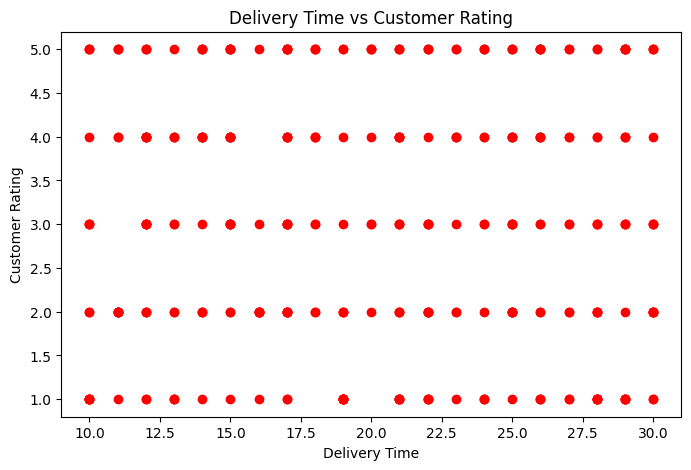

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df["delivery_time"],df["customer_rating"],color="red")
plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Time")
plt.ylabel("Customer Rating")
plt.show()

Highlight top revenue-generating restaurants.

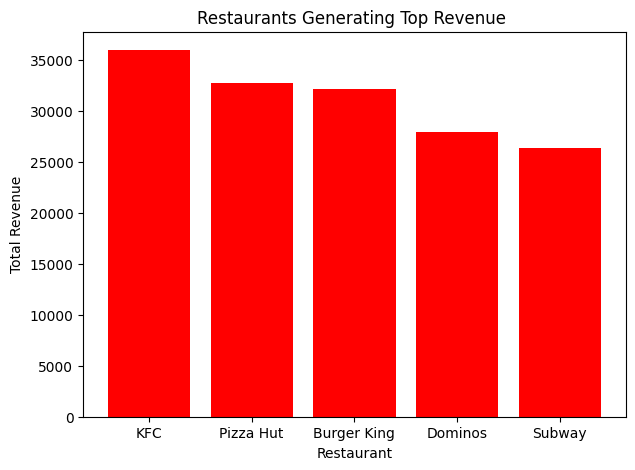

In [28]:
revenue=df.groupby("restaurant")["order_value"].sum()
top_revenue=revenue.sort_values(ascending=False).head(5)
plt.figure(figsize=(7,5))
plt.bar(top_revenue.index,top_revenue.values,color="red")
plt.title("Restaurants Generating Top Revenue ")
plt.xlabel("Restaurant")
plt.ylabel("Total Revenue")
plt.show()
